# Multiple Coulomb Scattering Analysis — Phantom B (Water–Bone–Water)

This notebook quantifies multiple Coulomb scattering (MCS) in a water–cortical bone–water phantom geometry using proton phase-space data from PHITS Monte Carlo simulations. **Phantom B** contains no implant material and serves as the bone-only reference configuration in a broader study examining how orthopedic implant materials alter proton beam transport.

Seven scoring planes (PSFB1–PSFB7) are positioned at sequential depth intervals along a 140 MeV parallel proton beam (5 × 5 cm² field, ~97 million primary proton histories per plane). Phase-space dump files from PHITS v3.34 are parsed in chunks to handle individual file sizes of ~27 GB. The angular distribution at each plane is fit with an annular-corrected Gaussian to extract the cumulative MCS angle θ₀, and per-layer contributions are isolated via successive variance subtraction (Fermi–Eyges transport theory).

**Pipeline overview**

| Step | Description |
|------|-------------|
| 1–2  | Mount Drive, import libraries |
| 3    | Configuration — edit only this cell to reuse for another phantom |
| 4–5  | Parse PHITS dump files → build θ histograms → cache to `.npz` |
| 6–7  | Save / reload histogram cache |
| 8    | Analysis functions: annular weighting, Gaussian fit, variance subtraction |
| 9    | Fit all planes, extract cumulative and material-only θ₀ |
| 10–12 | Summary table, distribution plots, bar chart |
| 13   | Export results to CSV |

Raw PHITS phase-space files are not included in the repository due to file size. Processed `.npz` histogram caches and result CSV files are provided in `data/processed/` and `results/`.

## 1. Environment setup

The analysis was developed in Google Colab, but the core functions use standard Python libraries. When the notebook is opened outside Colab, the Google Drive mount step is skipped.


In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
else:
    print("Google Colab is not detected. Drive mounting was skipped.")


Mounted at /content/drive


In [ ]:
import gc
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import curve_fit

print("Libraries loaded.")


Libraries loaded.


## 2. Project configuration

Only this section needs to be edited when the notebook is reused for another phantom or folder. The raw PHITS files should be placed in a local or Drive folder outside the GitHub repository, while processed histograms, plots, and CSV summaries can be saved in the `results/` and `data/processed/` folders.


In [ ]:
PHANTOM_NAME = "Phantom_B"

PROJECT_ROOT = Path("/content/drive/MyDrive/replace-with-your-project-folder")
DATA_DIR = PROJECT_ROOT
CACHE_DIR = PROJECT_ROOT / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / PHANTOM_NAME

CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PHASE_SPACE_FILES = [
    {"tag": "PSFB1", "label": "PSFB 1 (reference)", "filename": "PSFB1_dmp.out"},
    {"tag": "PSFB2", "label": "PSFB 2",             "filename": "PSFB2_dmp.out"},
    {"tag": "PSFB3", "label": "PSFB 3",             "filename": "PSFB3_dmp.out"},
    {"tag": "PSFB4", "label": "PSFB 4",             "filename": "PSFB4_dmp.out"},
    {"tag": "PSFB5", "label": "PSFB 5",             "filename": "PSFB5_dmp.out"},
    {"tag": "PSFB6", "label": "PSFB 6",             "filename": "PSFB6_dmp.out"},
    {"tag": "PSFB7", "label": "PSFB 7",             "filename": "PSFB7_dmp.out"},
]

FILES = [
    {**item, "path": DATA_DIR / item["filename"]}
    for item in PHASE_SPACE_FILES
]

REFERENCE_TAG = "PSFB1"

HIST_SAVE = CACHE_DIR / f"histograms_{PHANTOM_NAME}.npz"
PLOT_DIST = RESULTS_DIR / f"mcs_distributions_{PHANTOM_NAME}.png"
PLOT_BAR = RESULTS_DIR / f"mcs_summary_{PHANTOM_NAME}.png"
CSV_RESULTS = RESULTS_DIR / f"mcs_results_{PHANTOM_NAME}.csv"


## 3. Phase-space schema and analysis parameters

The PHITS dump file is expected to contain at least nine numeric columns. In this analysis, the relevant fields are particle ID (`KF`), direction cosines (`U`, `V`, `W`), energy, and statistical weight. The scattering angle is calculated from the beam-axis direction cosine:

\[
\theta = \cos^{-1}(W)
\]

The histogram range and fit settings below define how the angular distribution is summarized.


In [ ]:
COL_KF = 0
COL_U = 4
COL_V = 5
COL_W = 6
COL_E = 7
COL_WT = 8

KF_PROTON = 2212

BIN_MIN_DEG = 0.0
BIN_MAX_DEG = 20.0
N_BINS = 400

CORE_SIGMA_LIMIT = 2.5
MIN_COUNT_PER_BIN = 5
CHUNK_LINES = 50_000
DEG_TO_MRAD = 1000.0 * np.pi / 180.0

bins = np.linspace(BIN_MIN_DEG, BIN_MAX_DEG, N_BINS + 1)
theta_centers = 0.5 * (bins[:-1] + bins[1:])


## 4. Input validation

This step checks whether the configured file names exist. Missing files are not treated as a hard failure because some phantom configurations may contain fewer scoring planes.


In [ ]:
print(f"Phantom: {PHANTOM_NAME}")
print(f"Raw data folder: {DATA_DIR}")
print()

all_found = True
for item in FILES:
    found = item["path"].exists()
    all_found = all_found and found
    status = "FOUND" if found else "NOT FOUND"
    print(f"{item['tag']:6s} | {status:9s} | {item['filename']}")

if all_found:
    print("\nAll configured files were found.")
else:
    print("\nSome files were not found. Check DATA_DIR or remove unused files from PHASE_SPACE_FILES.")


Phantom: Phantom_B
Raw data folder: /content/drive/MyDrive/replace-with-your-project-folder

PSFB1  | FOUND     | PSFB1_dmp.out
PSFB2  | FOUND     | PSFB2_dmp.out
PSFB3  | FOUND     | PSFB3_dmp.out
PSFB4  | FOUND     | PSFB4_dmp.out
PSFB5  | FOUND     | PSFB5_dmp.out
PSFB6  | FOUND     | PSFB6_dmp.out
PSFB7  | FOUND     | PSFB7_dmp.out

All configured files were found.


## 5. Read PHITS phase-space files

Large phase-space files are processed in chunks. Instead of loading the full file into memory, each chunk is parsed, filtered to proton rows, converted to angular values, and added directly to a histogram. This keeps the notebook usable even when the raw files are too large for GitHub.


In [ ]:
def _parse_buffer(buffer):
    """
    Parse a block of PHITS phase-space text lines and keep proton rows only.

    Parameters
    ----------
    buffer : list of str
        Raw text lines from a PHITS dump file after comment and empty lines
        have been removed.

    Returns
    -------
    numpy.ndarray or None
        A float32 array containing proton rows. Returns None when the buffer
        has no valid proton records.
    """
    rows = []

    for line in buffer:
        try:
            values = list(map(float, line.split()))
        except ValueError:
            continue

        if len(values) < 9:
            continue

        if int(values[COL_KF]) == KF_PROTON:
            rows.append(values)

    if not rows:
        return None

    return np.asarray(rows, dtype=np.float32)


def read_phits_psf(filepath, chunk_lines=CHUNK_LINES):
    """
    Yield proton data chunks from a PHITS phase-space dump file.

    The function reads the file line by line, skips comments and empty lines,
    converts Fortran-style exponents to Python-readable notation, and yields
    only rows where the PHITS particle code corresponds to protons.

    Parameters
    ----------
    filepath : str or pathlib.Path
        Path to a PHITS phase-space dump file.
    chunk_lines : int, default CHUNK_LINES
        Number of numeric lines parsed per chunk.

    Yields
    ------
    numpy.ndarray
        A chunk of proton rows from the phase-space file.
    """
    filepath = Path(filepath)
    total_bytes = filepath.stat().st_size
    total_mb = total_bytes / (1024 * 1024)

    print(f"Reading {filepath.name} ({total_mb:,.1f} MB)")
    sys.stdout.flush()

    buffer = []
    bytes_read = 0
    skipped = 0
    proton_count = 0
    next_progress = 10

    with filepath.open("r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            bytes_read += len(line.encode("utf-8"))
            line = line.strip()

            if not line or line.startswith("#") or line.startswith("$"):
                skipped += 1
                continue

            buffer.append(line.replace("D", "e").replace("d", "e"))

            if len(buffer) >= chunk_lines:
                rows = _parse_buffer(buffer)
                buffer = []

                if rows is not None:
                    proton_count += len(rows)
                    yield rows

                progress = int(min(bytes_read / total_bytes * 100, 99))
                if progress >= next_progress:
                    print(f"  {progress:3d}% complete | protons parsed: {proton_count:,}")
                    sys.stdout.flush()
                    next_progress += 10

                gc.collect()

    if buffer:
        rows = _parse_buffer(buffer)
        if rows is not None:
            proton_count += len(rows)
            yield rows

    print(f"  100% complete | protons parsed: {proton_count:,} | skipped lines: {skipped:,}")
    sys.stdout.flush()


def build_theta_histogram(filepath, bin_edges_deg):
    """
    Build an angular histogram from one PHITS phase-space file.

    Parameters
    ----------
    filepath : str or pathlib.Path
        Path to the phase-space dump file.
    bin_edges_deg : numpy.ndarray
        Histogram bin edges in degrees.

    Returns
    -------
    tuple
        A pair `(hist, n_total)` where `hist` contains proton counts inside
        the selected angular range and `n_total` is the total number of proton
        rows processed.
    """
    hist = np.zeros(len(bin_edges_deg) - 1, dtype=np.int64)
    n_total = 0

    for chunk in read_phits_psf(filepath):
        w_values = np.clip(chunk[:, COL_W], -1.0, 1.0)
        theta_deg = np.degrees(np.arccos(w_values))

        chunk_hist, _ = np.histogram(theta_deg, bins=bin_edges_deg)
        hist += chunk_hist
        n_total += len(theta_deg)

        del chunk, w_values, theta_deg
        gc.collect()

    return hist, n_total


## 6. Build angular histograms from raw files

Run this section when the raw `.out` files are available. The resulting histograms are much smaller than the original phase-space files and can be reused for later analysis.


In [ ]:
HISTS = {}
N_PROTONS = {}
N_OUTSIDE_RANGE = {}

for index, item in enumerate(FILES, start=1):
    tag = item["tag"]
    label = item["label"]
    path = item["path"]

    print()
    print("=" * 70)
    print(f"File {index} of {len(FILES)}: {label}")
    print("=" * 70)

    if not path.exists():
        print(f"Skipped: {path}")
        continue

    hist, n_total = build_theta_histogram(path, bins)
    n_in_range = int(hist.sum())
    n_outside = int(n_total - n_in_range)

    HISTS[tag] = hist
    N_PROTONS[tag] = n_in_range
    N_OUTSIDE_RANGE[tag] = n_outside

    print(f"Protons inside histogram range : {n_in_range:,}")
    print(f"Protons outside histogram range: {n_outside:,}")

print()
print("Histogram building completed.")



File 1 of 7: PSFB 1 (reference)
Reading PSFB1_dmp.out (26,970.0 MB)
   10% complete | protons parsed: 9,794,440
   20% complete | protons parsed: 19,542,577
   30% complete | protons parsed: 29,335,961
   40% complete | protons parsed: 39,086,328
   50% complete | protons parsed: 48,882,678
   60% complete | protons parsed: 58,632,345
   70% complete | protons parsed: 68,427,496
   80% complete | protons parsed: 78,177,213
   90% complete | protons parsed: 87,927,617
  100% complete | protons parsed: 97,326,797 | skipped lines: 0
Protons inside histogram range : 94,944,180
Protons outside histogram range: 2,382,617

File 2 of 7: PSFB 2
Reading PSFB2_dmp.out (27,020.5 MB)
   10% complete | protons parsed: 9,724,720
   20% complete | protons parsed: 19,448,847
   30% complete | protons parsed: 29,173,137
   40% complete | protons parsed: 38,899,923
   50% complete | protons parsed: 48,625,737
   60% complete | protons parsed: 58,351,391
   70% complete | protons parsed: 68,031,677
   80

## 7. Save or reload histogram cache

After the first full run, the cache file can be loaded directly. This avoids repeatedly reading large raw PHITS outputs during notebook development.


In [ ]:
def save_histogram_cache(cache_path, bin_edges, bin_centers, histograms, proton_counts, outside_counts):
    """
    Save processed angular histograms into a compressed NumPy archive.

    Parameters
    ----------
    cache_path : str or pathlib.Path
        Output path for the `.npz` cache file.
    bin_edges : numpy.ndarray
        Histogram bin edges in degrees.
    bin_centers : numpy.ndarray
        Histogram bin centers in degrees.
    histograms : dict
        Mapping of phase-space tag to histogram counts.
    proton_counts : dict
        Mapping of phase-space tag to counts inside the selected angle range.
    outside_counts : dict
        Mapping of phase-space tag to counts outside the selected angle range.
    """
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        cache_path,
        bins=bin_edges,
        theta_centers=bin_centers,
        **{f"hist_{tag}": hist for tag, hist in histograms.items()},
        **{f"n_{tag}": np.array([count]) for tag, count in proton_counts.items()},
        **{f"outside_{tag}": np.array([count]) for tag, count in outside_counts.items()},
    )

    print(f"Saved histogram cache: {cache_path}")


def load_histogram_cache(cache_path):
    """
    Load processed angular histograms from a NumPy archive.

    Parameters
    ----------
    cache_path : str or pathlib.Path
        Path to a previously saved `.npz` histogram cache.

    Returns
    -------
    tuple
        `(bins, theta_centers, histograms, proton_counts, outside_counts)`.
    """
    cache_path = Path(cache_path)
    loaded = np.load(cache_path)

    histograms = {}
    proton_counts = {}
    outside_counts = {}

    for key in loaded.files:
        if key.startswith("hist_"):
            tag = key.replace("hist_", "", 1)
            histograms[tag] = loaded[key]
        elif key.startswith("n_"):
            tag = key.replace("n_", "", 1)
            proton_counts[tag] = int(loaded[key][0])
        elif key.startswith("outside_"):
            tag = key.replace("outside_", "", 1)
            outside_counts[tag] = int(loaded[key][0])

    return loaded["bins"], loaded["theta_centers"], histograms, proton_counts, outside_counts


In [ ]:
# Run this after building histograms from raw files.
if HISTS:
    save_histogram_cache(
        HIST_SAVE,
        bins,
        theta_centers,
        HISTS,
        N_PROTONS,
        N_OUTSIDE_RANGE,
    )
else:
    print("No histograms are currently available in memory. Cache saving was skipped.")


Saved histogram cache: /content/drive/MyDrive/replace-with-your-project-folder/processed/histograms_Phantom_B.npz


In [ ]:
# Run this instead of rebuilding histograms when a cache file already exists.
bins, theta_centers, HISTS, N_PROTONS, N_OUTSIDE_RANGE = load_histogram_cache(HIST_SAVE)

print(f"Loaded histogram cache: {HIST_SAVE}")
print()
for tag in HISTS:
    label = next((item["label"] for item in FILES if item["tag"] == tag), tag)
    print(f"{tag:6s} | {label:25s} | {N_PROTONS[tag]:>12,} protons")


Loaded histogram cache: /content/drive/MyDrive/replace-with-your-project-folder/processed/histograms_Phantom_B.npz

PSFB1  | PSFB 1 (reference)        |   94,944,180 protons
PSFB2  | PSFB 2                    |   94,403,874 protons
PSFB3  | PSFB 3                    |   93,577,266 protons
PSFB4  | PSFB 4                    |   93,013,388 protons
PSFB5  | PSFB 5                    |   92,142,646 protons
PSFB6  | PSFB 6                    |   91,558,866 protons
PSFB7  | PSFB 7                    |   67,200,661 protons


## 8. Scattering analysis functions

The raw angular histogram is converted into an annular-weighted distribution before fitting. A Gaussian fit is applied to the core region of the angular distribution, while the material-only contribution is estimated using variance subtraction between consecutive scoring planes.


In [ ]:
def apply_annular_weight(hist, bin_edges_deg):
    """
    Convert angular counts into annular-weighted counts.

    Small-angle histograms represent rings in angular space. Dividing by the
    annular area prevents outer bins from appearing larger only because their
    angular area is larger.

    Parameters
    ----------
    hist : numpy.ndarray
        Raw histogram counts.
    bin_edges_deg : numpy.ndarray
        Histogram bin edges in degrees.

    Returns
    -------
    numpy.ndarray
        Annular-weighted histogram counts.
    """
    edges_rad = np.deg2rad(bin_edges_deg)
    theta_1 = edges_rad[:-1]
    theta_2 = edges_rad[1:]
    area = np.pi * (theta_2**2 - theta_1**2)
    area = np.where(area > 0, area, np.nan)

    weighted = hist.astype(np.float64) / area
    return np.nan_to_num(weighted, nan=0.0)


def gaussian_mcs(theta_deg, amplitude, theta0_deg):
    """
    Evaluate a Gaussian model for the core multiple-scattering distribution.

    Parameters
    ----------
    theta_deg : array-like
        Scattering angle in degrees.
    amplitude : float
        Peak amplitude of the distribution.
    theta0_deg : float
        Gaussian width parameter in degrees.

    Returns
    -------
    array-like
        Model values at the requested angular positions.
    """
    return amplitude * np.exp(-(theta_deg**2) / (2.0 * theta0_deg**2))


def fit_theta0(
    theta_centers_deg,
    weighted_hist,
    raw_hist,
    core_limit=CORE_SIGMA_LIMIT,
    min_count=MIN_COUNT_PER_BIN,
):
    """
    Estimate the Gaussian width of an angular distribution.

    The function first removes low-count bins, estimates a preliminary width
    from the weighted second moment, and fits only the core region defined by
    `core_limit * preliminary_sigma`.

    Parameters
    ----------
    theta_centers_deg : numpy.ndarray
        Histogram bin centers in degrees.
    weighted_hist : numpy.ndarray
        Annular-weighted histogram counts.
    raw_hist : numpy.ndarray
        Original histogram counts before annular weighting.
    core_limit : float, default CORE_SIGMA_LIMIT
        Multiplier used to define the fitted core region.
    min_count : int, default MIN_COUNT_PER_BIN
        Minimum raw count required for a bin to be included.

    Returns
    -------
    tuple
        `(theta0_deg, theta0_mrad, info)` where `info` stores fit diagnostics.
        If the fit fails, the first two values are None.
    """
    valid = (raw_hist >= min_count) & (weighted_hist > 0)

    if valid.sum() < 4:
        return None, None, {"error": "not enough valid bins"}

    theta_valid = theta_centers_deg[valid]
    weights_valid = weighted_hist[valid]
    sigma_est = np.sqrt(np.sum(weights_valid * theta_valid**2) / np.sum(weights_valid))

    core = valid & (theta_centers_deg <= core_limit * sigma_est)
    if core.sum() < 4:
        core = valid

    theta_fit = theta_centers_deg[core]
    y_fit = weighted_hist[core]

    try:
        popt, pcov = curve_fit(
            gaussian_mcs,
            theta_fit,
            y_fit,
            p0=[np.max(y_fit), sigma_est],
            bounds=([0.0, 1e-6], [np.inf, 90.0]),
            maxfev=10_000,
        )

        amplitude_fit, theta0_fit_deg = popt
        parameter_error = np.sqrt(np.diag(pcov))

        info = {
            "sigma_est_deg": float(sigma_est),
            "fit_limit_deg": float(core_limit * sigma_est),
            "n_bins_in_fit": int(core.sum()),
            "amplitude_fit": float(amplitude_fit),
            "theta0_err_deg": float(parameter_error[1]),
        }

        return float(theta0_fit_deg), float(theta0_fit_deg * DEG_TO_MRAD), info

    except Exception as exc:
        return None, None, {"error": str(exc)}


def deconvolve(theta_after_mrad, theta_before_mrad, label=""):
    """
    Estimate material-only angular broadening using variance subtraction.

    Parameters
    ----------
    theta_after_mrad : float
        Cumulative Gaussian width after the current layer.
    theta_before_mrad : float
        Cumulative Gaussian width before the current layer.
    label : str, optional
        Label used in warning messages.

    Returns
    -------
    float
        Deconvolved material-only contribution in milliradians.
    """
    variance_difference = theta_after_mrad**2 - theta_before_mrad**2

    if variance_difference <= 0:
        print(f"Warning [{label}]: downstream width is not larger than upstream width. Returning 0.")
        return 0.0

    return float(np.sqrt(variance_difference))


## 9. Fit angular distributions and calculate material-only scattering

The reference plane is treated as the upstream baseline. For subsequent planes, the material-only contribution is computed from the difference in fitted variances. This interpretation assumes that consecutive broadening contributions can be combined approximately in quadrature.


In [ ]:
results = {}
tags_in_order = [item["tag"] for item in FILES if item["tag"] in HISTS]

print("=" * 70)
print(f"MCS analysis: {PHANTOM_NAME}")
print("=" * 70)

for tag in tags_in_order:
    label = next(item["label"] for item in FILES if item["tag"] == tag)
    raw_hist = HISTS[tag]
    weighted_hist = apply_annular_weight(raw_hist, bins)
    theta0_deg, theta0_mrad, fit_info = fit_theta0(theta_centers, weighted_hist, raw_hist)

    results[tag] = {
        "label": label,
        "n_protons": N_PROTONS[tag],
        "n_outside_range": N_OUTSIDE_RANGE.get(tag, 0),
        "raw": raw_hist,
        "weighted": weighted_hist,
        "theta0_deg": theta0_deg,
        "theta0_mrad": theta0_mrad,
        "theta0_material_mrad": None,
        "fit_info": fit_info,
    }

    print()
    print(f"[{label}]")
    print(f"  Protons inside range : {N_PROTONS[tag]:,}")
    print(f"  Protons outside range: {N_OUTSIDE_RANGE.get(tag, 0):,}")

    if theta0_deg is None:
        print(f"  Fit status           : failed ({fit_info.get('error', 'unknown error')})")
    else:
        print(f"  theta0 total         : {theta0_deg:.5f} deg = {theta0_mrad:.4f} mrad")
        print(f"  Fit range            : 0 to {fit_info['fit_limit_deg']:.4f} deg")
        print(f"  Bins in fit          : {fit_info['n_bins_in_fit']}")

reference = results.get(REFERENCE_TAG)

if reference and reference["theta0_mrad"] is not None:
    previous_theta0 = reference["theta0_mrad"]
    results[REFERENCE_TAG]["theta0_material_mrad"] = previous_theta0

    print()
    print("=" * 70)
    print("Deconvolution")
    print("=" * 70)
    print(f"Reference {REFERENCE_TAG}: {previous_theta0:.4f} mrad")

    for tag in tags_in_order:
        if tag == REFERENCE_TAG:
            continue

        current_theta0 = results[tag]["theta0_mrad"]
        if current_theta0 is None:
            continue

        material_theta0 = deconvolve(current_theta0, previous_theta0, label=tag)
        results[tag]["theta0_material_mrad"] = material_theta0

        print()
        print(f"[{results[tag]['label']}]")
        print(f"  Total theta0    : {current_theta0:.4f} mrad")
        print(f"  Previous theta0 : {previous_theta0:.4f} mrad")
        print(f"  Material theta0 : {material_theta0:.4f} mrad")

        previous_theta0 = current_theta0
else:
    print("Reference tag was not found or its fit failed.")


MCS analysis: Phantom_B

[PSFB 1 (reference)]
  Protons inside range : 94,944,180
  Protons outside range: 2,382,617
  theta0 total         : 1.04945 deg = 18.3164 mrad
  Fit range            : 0 to 3.0332 deg
  Bins in fit          : 61

[PSFB 2]
  Protons inside range : 94,403,874
  Protons outside range: 2,412,559
  theta0 total         : 1.17705 deg = 20.5435 mrad
  Fit range            : 0 to 3.4015 deg
  Bins in fit          : 68

[PSFB 3]
  Protons inside range : 93,577,266
  Protons outside range: 2,423,846
  theta0 total         : 1.34523 deg = 23.4787 mrad
  Fit range            : 0 to 3.9003 deg
  Bins in fit          : 78

[PSFB 4]
  Protons inside range : 93,013,388
  Protons outside range: 2,419,344
  theta0 total         : 1.46254 deg = 25.5262 mrad
  Fit range            : 0 to 4.2477 deg
  Bins in fit          : 85

[PSFB 5]
  Protons inside range : 92,142,646
  Protons outside range: 2,396,889
  theta0 total         : 1.62574 deg = 28.3745 mrad
  Fit range            

## 10. Summary table

This table is the main tabular output of the notebook. It is also exported as a CSV file in the final step.


In [ ]:
summary_rows = []

for tag in tags_in_order:
    item = results[tag]
    summary_rows.append({
        "phantom": PHANTOM_NAME,
        "psf": tag,
        "label": item["label"],
        "n_protons": item["n_protons"],
        "n_outside_range": item["n_outside_range"],
        "theta0_total_deg": item["theta0_deg"],
        "theta0_total_mrad": item["theta0_mrad"],
        "theta0_material_mrad": item["theta0_material_mrad"],
        "fit_limit_deg": item["fit_info"].get("fit_limit_deg"),
        "n_bins_in_fit": item["fit_info"].get("n_bins_in_fit"),
        "theta0_err_deg": item["fit_info"].get("theta0_err_deg"),
    })

df_results = pd.DataFrame(summary_rows)
display(df_results)


,phantom,psf,label,n_protons,n_outside_range,theta0_total_deg,theta0_total_mrad,theta0_material_mrad,fit_limit_deg,n_bins_in_fit,theta0_err_deg
0,Phantom_B,PSFB1,PSFB 1 (reference),94944180,2382617,1.049454,18.316436,18.316436,3.033218,61,0.001174
1,Phantom_B,PSFB2,PSFB 2,94403874,2412559,1.177055,20.543478,9.302830,3.401490,68,0.001180
2,Phantom_B,PSFB3,PSFB 3,93577266,2423846,1.345228,23.478651,11.367170,3.900262,78,0.001255
3,Phantom_B,PSFB4,PSFB 4,93013388,2419344,1.462545,25.526221,10.017032,4.247681,85,0.001553
4,Phantom_B,PSFB5,PSFB 5,92142646,2396889,1.625742,28.374548,12.390601,4.737179,95,0.001642
5,Phantom_B,PSFB6,PSFB 6,91558866,2375347,1.741101,30.387946,10.877145,5.079234,102,0.001413
6,Phantom_B,PSFB7,PSFB 7,67200661,1130129,3.287123,57.371121,48.662288,9.127648,183,0.003932


## 11. Angular distribution plots

The first figure compares the annular-weighted angular histogram with the fitted Gaussian core for each phase-space plane. The fitted core is shown separately from the broader tail because the tail may contain non-Gaussian scattering components.


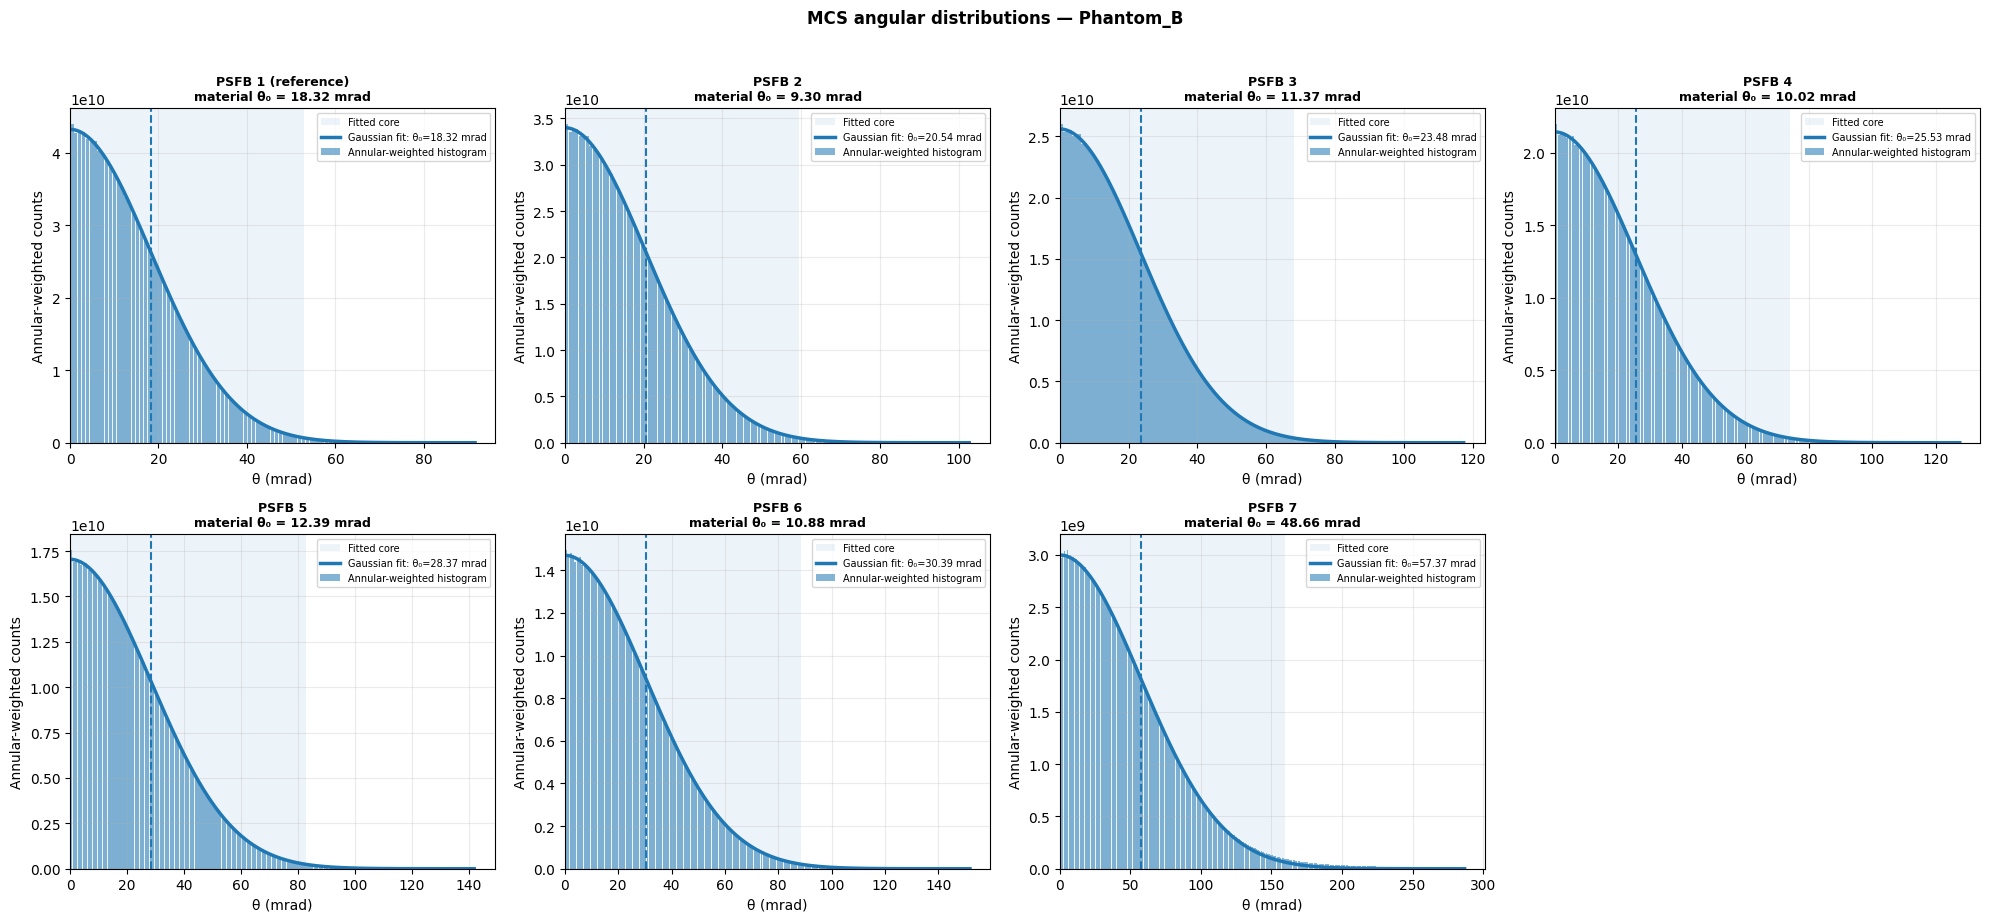

Saved figure: /content/drive/MyDrive/replace-with-your-project-folder/results/Phantom_B/mcs_distributions_Phantom_B.png


In [ ]:
n_plots = len(tags_in_order)

if n_plots == 0:
    raise ValueError("No histograms are available. Build or load histogram cache first.")

n_cols = min(4, n_plots)
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
)
axes = axes.flatten()

for index, tag in enumerate(tags_in_order):
    ax = axes[index]
    item = results[tag]
    theta0_deg = item["theta0_deg"]
    theta0_mrad = item["theta0_mrad"]
    fit_info = item["fit_info"]

    max_plot_deg = min(BIN_MAX_DEG, theta0_deg * 5.0) if theta0_deg else BIN_MAX_DEG
    mask = theta_centers <= max_plot_deg

    x_mrad = theta_centers[mask] * DEG_TO_MRAD
    bar_width_mrad = (bins[1] - bins[0]) * DEG_TO_MRAD

    ax.bar(
        x_mrad,
        item["weighted"][mask],
        width=bar_width_mrad * 0.85,
        alpha=0.55,
        label="Annular-weighted histogram",
    )

    if theta0_deg and "amplitude_fit" in fit_info:
        fit_limit_mrad = fit_info["fit_limit_deg"] * DEG_TO_MRAD
        x_fit_deg = np.linspace(0, max_plot_deg, 500)
        y_fit = gaussian_mcs(x_fit_deg, fit_info["amplitude_fit"], theta0_deg)

        ax.axvspan(0, fit_limit_mrad, alpha=0.08, label="Fitted core")
        ax.plot(
            x_fit_deg * DEG_TO_MRAD,
            y_fit,
            linewidth=2.5,
            label=f"Gaussian fit: θ₀={theta0_mrad:.2f} mrad",
        )
        ax.axvline(theta0_mrad, linestyle="--", linewidth=1.5)

    material_theta0 = item["theta0_material_mrad"]
    material_label = (
        f"\nmaterial θ₀ = {material_theta0:.2f} mrad"
        if material_theta0 is not None
        else ""
    )

    ax.set_title(f"{item['label']}{material_label}", fontsize=9, fontweight="bold")
    ax.set_xlabel("θ (mrad)")
    ax.set_ylabel("Annular-weighted counts")
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, loc="upper right")

for index in range(n_plots, len(axes)):
    axes[index].set_visible(False)

fig.suptitle(f"MCS angular distributions — {PHANTOM_NAME}", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIST, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {PLOT_DIST}")


## 12. Cumulative versus material-only scattering

The second figure separates the fitted cumulative broadening from the estimated material-only contribution. This makes it easier to identify which layer contributes most strongly to additional angular spread.


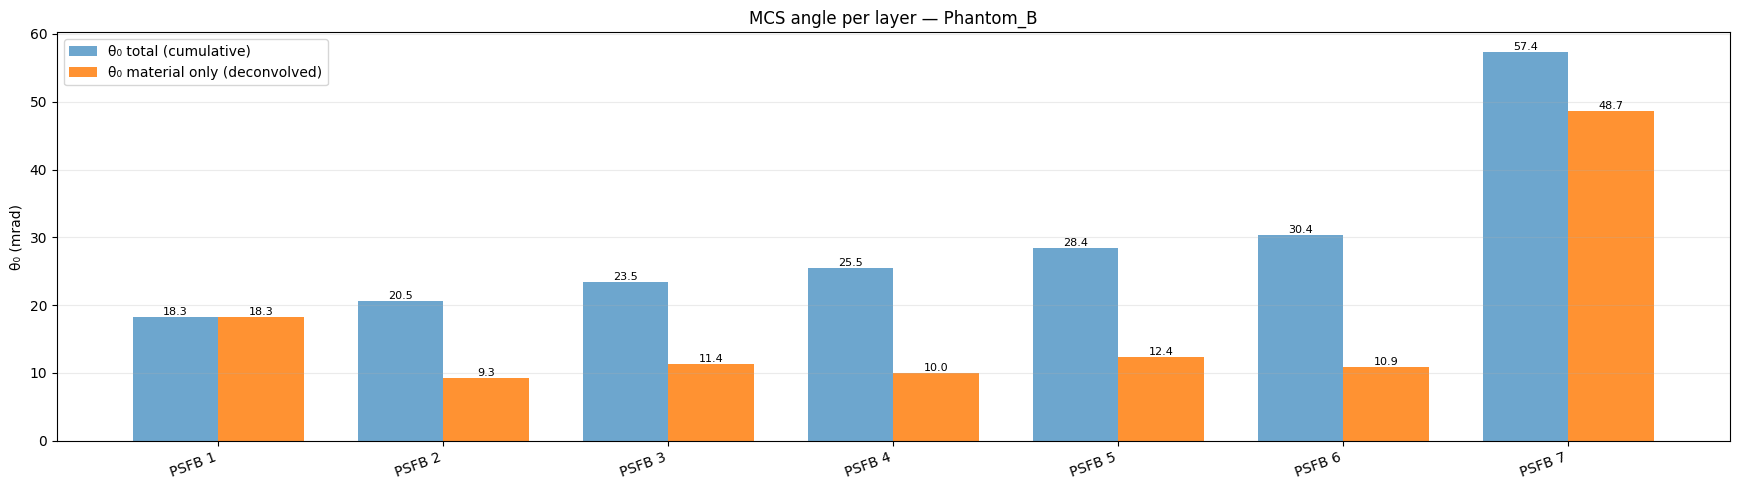

Saved figure: /content/drive/MyDrive/replace-with-your-project-folder/results/Phantom_B/mcs_summary_Phantom_B.png


In [ ]:
labels_plot = [
    results[tag]["label"].replace(" (reference)", "")
    for tag in tags_in_order
]
total_values = [
    results[tag]["theta0_mrad"] if results[tag]["theta0_mrad"] is not None else 0.0
    for tag in tags_in_order
]
material_values = [
    results[tag]["theta0_material_mrad"] if results[tag]["theta0_material_mrad"] is not None else 0.0
    for tag in tags_in_order
]

x = np.arange(len(tags_in_order))
width = 0.38

fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(tags_in_order)), 5))

bars_total = ax.bar(
    x - width / 2,
    total_values,
    width,
    label="θ₀ total (cumulative)",
    alpha=0.65,
)
bars_material = ax.bar(
    x + width / 2,
    material_values,
    width,
    label="θ₀ material only (deconvolved)",
    alpha=0.85,
)

for bar in list(bars_total) + list(bars_material):
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=20, ha="right")
ax.set_ylabel("θ₀ (mrad)")
ax.set_title(f"MCS angle per layer — {PHANTOM_NAME}")
ax.grid(True, alpha=0.25, axis="y")
ax.legend()
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(PLOT_BAR, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {PLOT_BAR}")


## 13. Export results

The final table is saved as a CSV file so it can be used in the repository README, thesis documentation, or downstream visualization tools.


In [ ]:
df_export = df_results.copy()

rounding_columns = [
    "theta0_total_deg",
    "theta0_total_mrad",
    "theta0_material_mrad",
    "fit_limit_deg",
    "theta0_err_deg",
]

for column in rounding_columns:
    if column in df_export.columns:
        df_export[column] = df_export[column].round(5)

df_export.to_csv(CSV_RESULTS, index=False)

print(f"Saved CSV: {CSV_RESULTS}")
display(df_export)


Saved CSV: /content/drive/MyDrive/replace-with-your-project-folder/results/Phantom_B/mcs_results_Phantom_B.csv


,phantom,psf,label,n_protons,n_outside_range,theta0_total_deg,theta0_total_mrad,theta0_material_mrad,fit_limit_deg,n_bins_in_fit,theta0_err_deg
0,Phantom_B,PSFB1,PSFB 1 (reference),94944180,2382617,1.04945,18.31644,18.31644,3.03322,61,0.00117
1,Phantom_B,PSFB2,PSFB 2,94403874,2412559,1.17705,20.54348,9.30283,3.40149,68,0.00118
2,Phantom_B,PSFB3,PSFB 3,93577266,2423846,1.34523,23.47865,11.36717,3.90026,78,0.00125
3,Phantom_B,PSFB4,PSFB 4,93013388,2419344,1.46254,25.52622,10.01703,4.24768,85,0.00155
4,Phantom_B,PSFB5,PSFB 5,92142646,2396889,1.62574,28.37455,12.39060,4.73718,95,0.00164
5,Phantom_B,PSFB6,PSFB 6,91558866,2375347,1.74110,30.38795,10.87715,5.07923,102,0.00141
6,Phantom_B,PSFB7,PSFB 7,67200661,1130129,3.28712,57.37112,48.66229,9.12765,183,0.00393


## Notes for repository use

The repository should not include full PHITS phase-space outputs if the files are too large. A practical GitHub structure is:

```text
data/
  processed/        # small cached histograms or sample processed outputs
results/
  Phantom_B/        # saved figures and CSV summaries
notebooks/
  Scattering_PSFB_portfolio_ready.ipynb
```

When the notebook is rerun and saved, GitHub will display the result tables and figures directly inside the notebook. The exported CSV and PNG files can also be referenced from the README.

The `PROJECT_ROOT` value is intentionally written as a placeholder for the public notebook. The displayed outputs were generated from the author's local PHITS phase-space files. To reproduce the analysis, change `PROJECT_ROOT` to the folder that contains the PHITS `.out` files, then rerun the notebook.
